# Kenya Land Valuation — Exploratory Data Analysis

**Best practice principles applied throughout this notebook:**
- One chart per cell — no facets or grouped panels
- Each chart title states the insight, not just the variable names
- Colour is used intentionally: sequential for continuous values, diverging for correlations
- Annotations guide the reader to the most important finding on each chart
- Log-transformed axes are used only where the data is right-skewed and the raw scale hides variation
- Every chart answers one specific question, stated clearly in the markdown before the code

| # | Chart | Question answered |
|---|-------|-------------------|
| 1 | Geospatial Scatter | Where is land expensive and where are large plots? |
| 2 | Choropleth | Which counties have the highest average land prices? |
| 3A | Nairobi Distance vs Price | How steeply does price fall as you move away from Nairobi? |
| 3B | Reference City Distance vs Price | Does distance from the local reference city matter beyond Nairobi's pull? |
| 4A | Amenities Score Distribution | How are amenities scores distributed across listings? |
| 4B | Accessibility Score Distribution | How are accessibility scores distributed across listings? |
| 4C | Infrastructure Score Distribution | How are infrastructure scores distributed across listings? |
| 5 | IDW Price Surface | What does the continuous land value landscape look like? |
| 6 | Top 5 Counties to Invest | Which counties offer the best balance of price and quality? |
| 7 | Size vs Price | Do larger parcels cost more per acre or less? |
| 8 | Correlation Matrix | Which features predict land price most strongly? |


## Cell 0 — Setup


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
from statsmodels.nonparametric.smoothers_lowess import lowess
warnings.filterwarnings("ignore")

PROJECT_ROOT = "/content/drive/MyDrive/kenya_land_valuation"
INTERIM_DATA = f"{PROJECT_ROOT}/data/interim"
OSM_DATA     = f"{PROJECT_ROOT}/data/osm"
OUTPUTS      = f"{PROJECT_ROOT}/outputs/eda"
os.makedirs(OUTPUTS, exist_ok=True)

# Colour palette — intentional and consistent across all charts
BLUE   = "#2E6DA4"
ORANGE = "#E8A838"
DARK   = "#1B3A5C"
GREEN  = "#2E8B57"
RED    = "#D9534F"
GREY   = "#888888"
LIGHT  = "#f5f5f5"

# Global style — clean, minimal, publication-ready
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 14,
    "axes.labelsize"   : 11,
    "axes.titlepad"    : 12,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

print("Setup complete.")


Mounted at /content/drive
Setup complete.


## Cell 1 — Load and Prepare Data


In [3]:
df = pd.read_parquet(f"{INTERIM_DATA}/kenya_land_engineered_final.parquet")

df = df[
    df["size_acres"].notna()     & (df["size_acres"]     > 0) &
    df["price_per_acre"].notna() & (df["price_per_acre"] > 0)
].copy().reset_index(drop=True)

# Clip outliers at 1st and 99th percentile
p01 = df["price_per_acre"].quantile(0.01)
p99 = df["price_per_acre"].quantile(0.99)
df  = df[(df["price_per_acre"] >= p01) & (df["price_per_acre"] <= p99)].copy().reset_index(drop=True)

# Log-transformed columns used in proximity and size charts
df["log_price_per_acre"] = np.log(df["price_per_acre"])
df["log_size_acres"]     = np.log(df["size_acres"].clip(lower=0.001))

# County shapefile
counties_gdf = gpd.read_file(f"{OSM_DATA}/kenya_counties.gpkg", layer="ADM_ADM_1")
counties_gdf = counties_gdf[["NAME_1","geometry"]].rename(columns={"NAME_1":"county"}).to_crs("EPSG:4326")

# GeoDataFrame of listings
geo_df = df[df["latitude"].notna() & df["longitude"].notna()].copy()
gdf    = gpd.GeoDataFrame(geo_df,
             geometry=gpd.points_from_xy(geo_df["longitude"], geo_df["latitude"]),
             crs="EPSG:4326")

# County price aggregates
county_stats = (df.groupby("county")["price_per_acre"]
                  .agg(mean_ppa="mean", median_ppa="median", count="count")
                  .reset_index())
counties_plot = counties_gdf.merge(county_stats, on="county", how="left")

# Major city reference points
CITIES = {
    "Nairobi" : (-1.2921, 36.8219),
    "Mombasa" : (-4.0435, 39.6682),
    "Kisumu"  : (-0.1022, 34.7617),
    "Nakuru"  : (-0.3031, 36.0800),
    "Eldoret" : ( 0.5143, 35.2698),
}

print(f"Listings ready for EDA : {len(df):,}")
print(f"With coordinates       : {len(gdf):,}")
print(f"Counties with data     : {county_stats['county'].nunique()}")


Listings ready for EDA : 796
With coordinates       : 796
Counties with data     : 30


## Chart 1 — Where Is Land Expensive and Where Are the Largest Plots in Kenya?

**Question:** Is there a geographic pattern linking high land prices to urban locations,
and do large parcels cluster away from cities as economic theory predicts?

**Best practice applied:**
- Size encodes a third variable (parcel size) without adding chart complexity
- Colour uses an intuitive sequential scale: red for expensive, green for cheap
- County boundaries provide geographic context without visual clutter
- City stars anchor the viewer spatially before they start reading the data points
- Colourbar labels show actual KSh values, not raw numbers

**How to interpret:** Red and orange dots near Nairobi and the coast confirm the urban land
price premium. Large dots (big parcels) appearing predominantly outside the dense clusters
around cities confirm that rural areas hold larger, cheaper land. Any large red dot far from
a city is a premium agricultural or tourism property worth investigating individually.


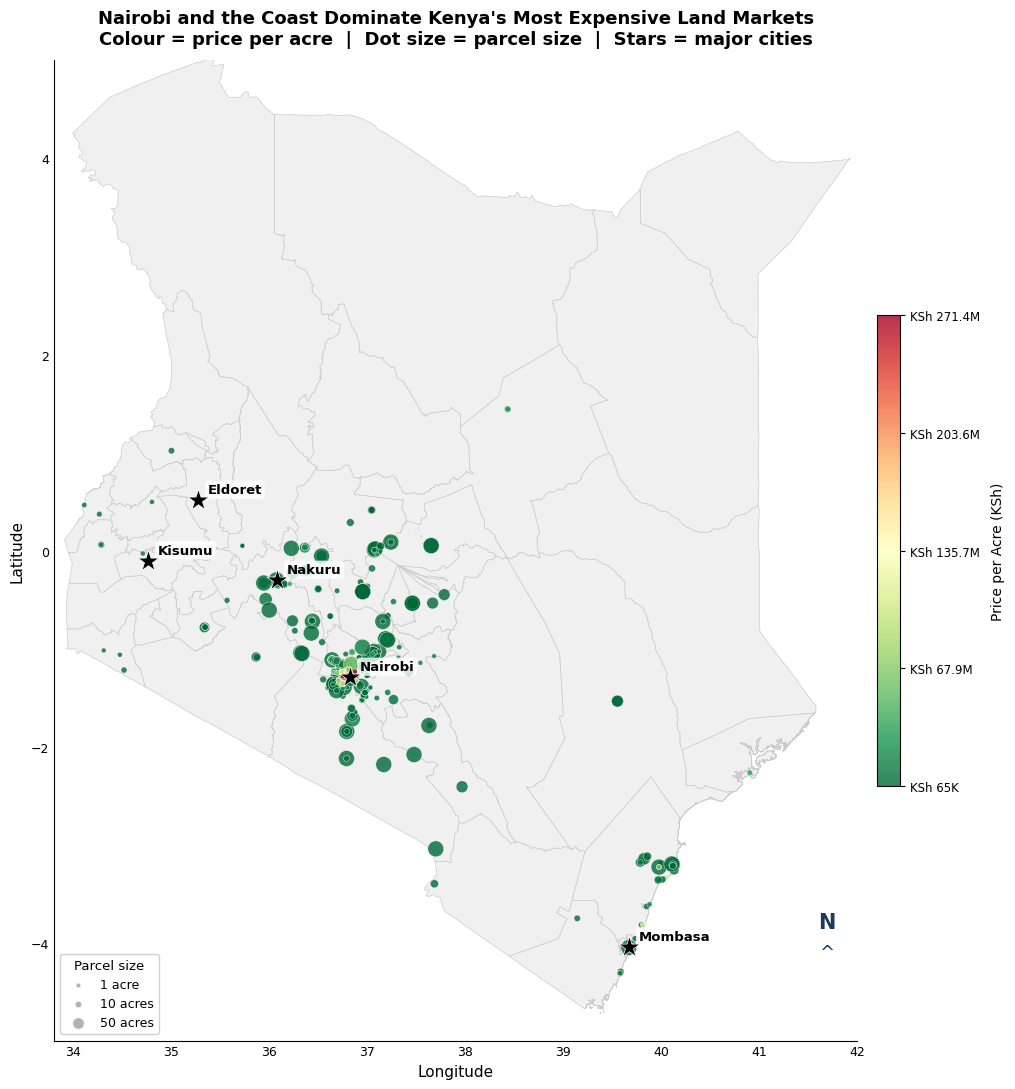

Saved: chart1_geospatial_scatter.png


In [4]:
import mapclassify

fig, ax = plt.subplots(figsize=(13, 11))

# Base layer — neutral grey county fills, minimal border
counties_gdf.plot(ax=ax, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.5, zorder=1)

# Dot size proportional to parcel size — capped so ranches do not dominate
dot_sizes = np.clip(gdf["size_acres"], 0.1, 100)
dot_sizes = (dot_sizes / dot_sizes.max() * 120) + 12

# Price colour — clipped to 5th-95th percentile for maximum colour contrast
price_clip = gdf["price_per_acre"].clip(
    lower=gdf["price_per_acre"].quantile(0.05),
    upper=gdf["price_per_acre"].quantile(0.95)
)

sc = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=price_clip, cmap="RdYlGn_r", s=dot_sizes,
    alpha=0.80, edgecolors="white", linewidths=0.35, zorder=3,
    norm=mcolors.Normalize(vmin=price_clip.quantile(0.05), vmax=price_clip.quantile(0.95))
)

# Colourbar — KSh labels, not raw numbers
cbar = plt.colorbar(sc, ax=ax, shrink=0.48, pad=0.015)
cbar.set_label("Price per Acre (KSh)", fontsize=10, labelpad=8)
tick_vals = np.linspace(price_clip.quantile(0.05), price_clip.quantile(0.95), 5)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(
    [f"KSh {v/1e6:.1f}M" if v >= 1e6 else f"KSh {v/1e3:.0f}K" for v in tick_vals],
    fontsize=8.5
)

# City markers — stars, bold labels, white halos for legibility
for city, (lat, lon) in CITIES.items():
    ax.scatter(lon, lat, marker="*", s=250, color="black",
               zorder=6, edgecolors="white", linewidths=0.5)
    ax.annotate(city, (lon, lat), textcoords="offset points", xytext=(7, 5),
                fontsize=9.5, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          alpha=0.80, edgecolor="none"))

# Parcel size legend
for sz_ac, lbl in [(1, "1 acre"), (10, "10 acres"), (50, "50 acres")]:
    s_scaled = (min(sz_ac, 100) / 100 * 120) + 12
    ax.scatter([], [], s=s_scaled, color=GREY, alpha=0.65,
               label=lbl, edgecolors="white")
ax.legend(title="Parcel size", loc="lower left",
          fontsize=9, title_fontsize=9.5, framealpha=0.92,
          edgecolor="#cccccc")

# North arrow
ax.annotate("N", xy=(0.962, 0.115), xycoords="axes fraction",
            fontsize=15, fontweight="bold", ha="center", color=DARK)
ax.annotate("^", xy=(0.962, 0.085), xycoords="axes fraction",
            fontsize=13, ha="center", color=DARK)

ax.set_title(
    "Nairobi and the Coast Dominate Kenya's Most Expensive Land Markets\n"
    "Colour = price per acre  |  Dot size = parcel size  |  Stars = major cities",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.set_xlim(33.8, 42.0)
ax.set_ylim(-5.0,  5.0)
ax.tick_params(which="both", length=0)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart1_geospatial_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart1_geospatial_scatter.png")


## Chart 2 — Urban Counties Command Premium Prices: A County-by-County Breakdown

**Question:** Which of Kenya's 47 counties have the highest average land prices,
and how unequal is the geographic distribution of land value?

**Best practice applied:**
- Fisher-Jenks natural breaks classification groups counties by where genuine price gaps exist in the data
- Every county with data carries its own price label (name + KSh)
- No-data counties are a distinct neutral grey that is clearly different from any class colour
- The legend uses actual KSh ranges, not index numbers
- Sequential YlOrRd palette: light yellow = affordable, dark red = most expensive

**How to interpret:** The darkest counties (Nairobi, Mombasa, Kiambu) confirm that proximity
to economic centres is the primary determinant of land value. The five natural break classes
reveal that the Kenyan market has distinct tiers — a small group of extremely expensive
urban counties, a mid-tier of peri-urban and coastal counties, and a large base of
affordable rural counties.


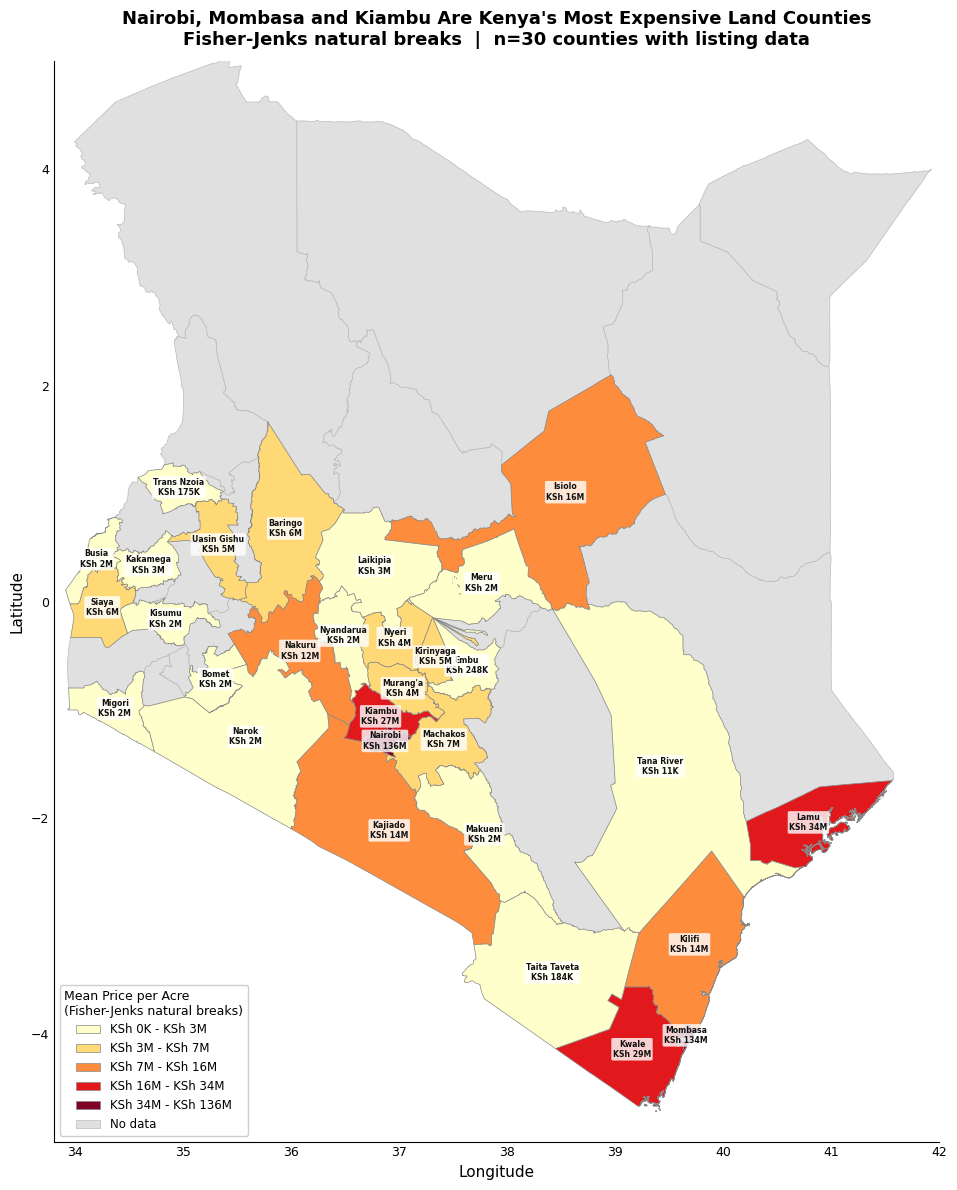

Saved: chart2_choropleth_mean_price.png


In [5]:
try:
    import mapclassify
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "mapclassify", "-q"])
    import mapclassify

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor("white")

# No-data counties — distinct grey, not part of the colour scale
counties_plot[counties_plot["mean_ppa"].isna()].plot(
    ax=ax, color="#e0e0e0", edgecolor="#bbbbbb", linewidth=0.5, zorder=1
)

# Counties with data — Fisher-Jenks 5-class YlOrRd
has_data = counties_plot["mean_ppa"].notna()
counties_plot[has_data].plot(
    column="mean_ppa", ax=ax, cmap="YlOrRd",
    scheme="FisherJenks", k=5,
    edgecolor="#888888", linewidth=0.5, zorder=2, legend=False
)

# Build class break legend manually with real KSh labels
fj         = mapclassify.FisherJenks(counties_plot.loc[has_data, "mean_ppa"].values, k=5)
bins       = [0] + list(fj.bins)
class_cols = [plt.cm.YlOrRd(i / 4) for i in range(5)]
def fmt_ksh(v):
    return f"KSh {v/1e6:.0f}M" if v >= 1e6 else f"KSh {v/1e3:.0f}K"
patches = [mpatches.Patch(facecolor=class_cols[i], edgecolor="#888888",
                           linewidth=0.5,
                           label=f"{fmt_ksh(bins[i])} - {fmt_ksh(bins[i+1])}")
           for i in range(5)]
patches.append(mpatches.Patch(facecolor="#e0e0e0", edgecolor="#bbbbbb",
                               linewidth=0.5, label="No data"))
ax.legend(handles=patches,
          title="Mean Price per Acre\n(Fisher-Jenks natural breaks)",
          title_fontsize=9, fontsize=8.5, loc="lower left",
          framealpha=0.94, edgecolor="#cccccc")

# Per-county price label on every county with data
for _, row in counties_plot[has_data].iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    v      = row["mean_ppa"]
    label  = f"{row['county']}\n{fmt_ksh(v)}"
    ax.annotate(label, xy=(cx, cy), ha="center", va="center",
                fontsize=5.6, color="#111111", fontweight="bold", zorder=5,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          alpha=0.80, edgecolor="none"))

ax.set_title(
    "Nairobi, Mombasa and Kiambu Are Kenya's Most Expensive Land Counties\n"
    f"Fisher-Jenks natural breaks  |  n={has_data.sum()} counties with listing data",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.set_xlim(33.8, 42.0)
ax.set_ylim(-5.0,  5.0)
ax.tick_params(which="both", length=0)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart2_choropleth_mean_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart2_choropleth_mean_price.png")


## Chart 3A — Land Price Decays Exponentially as Distance from Nairobi Increases

**Question:** How steeply does log(price per acre) fall as a listing moves further
from Nairobi CBD, and is there a distance threshold where the gradient flattens?

**Best practice applied:**
- Log-transformed price (y-axis) reveals the full spread of the data
- LOWESS curve instead of a straight trend line — the relationship is non-linear
- A vertical reference line at 50 km marks the approximate Nairobi commuter belt boundary
- Pearson r is annotated on the chart
- Binned medians (orange dots) give a cleaner view of the average trend at each distance band

**How to interpret:** The steep downward slope in the 0–50 km band is the commuter belt premium.
Beyond 100 km the curve flattens as Nairobi's gravitational influence weakens and local factors
take over. A Pearson r more negative than −0.3 confirms this is one of the strongest predictors
of land price in the dataset.


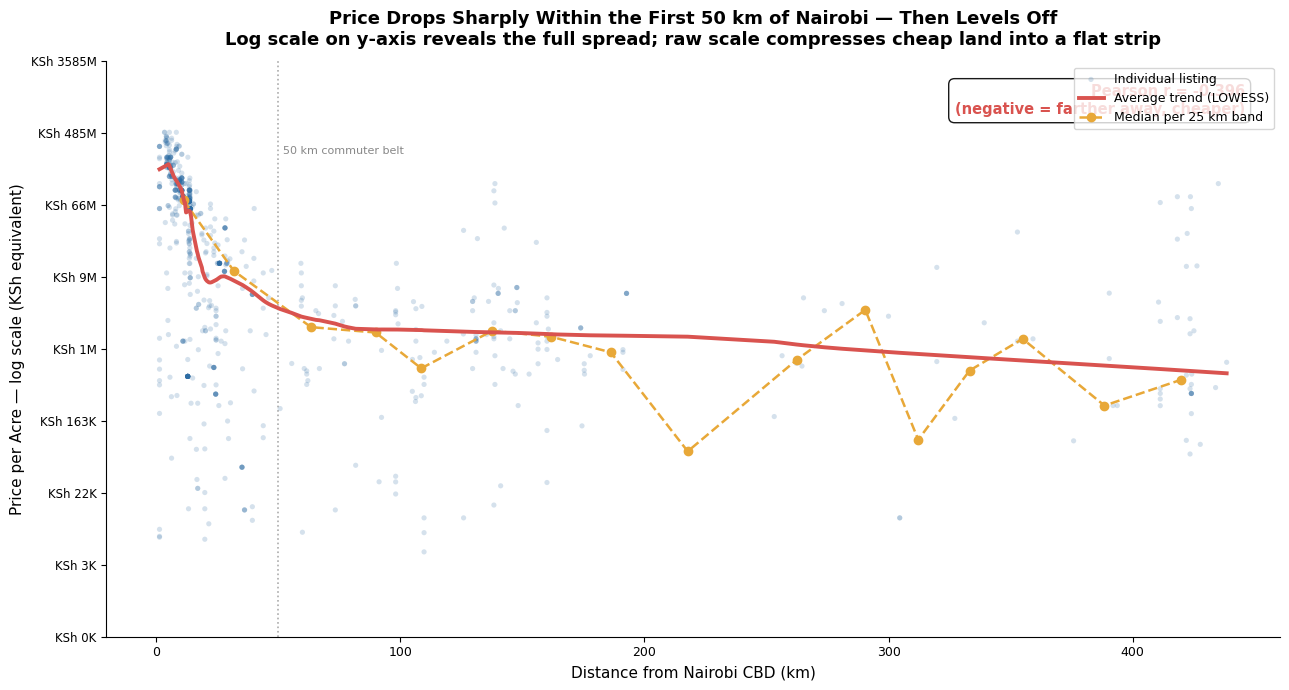

Pearson r: -0.396


In [6]:
plot_df = df[df["dist_to_nairobi_km"].notna() &
             (df["dist_to_nairobi_km"] <= df["dist_to_nairobi_km"].quantile(0.98))].copy()

fig, ax = plt.subplots(figsize=(13, 7))

# Scatter — semi-transparent so density is visible
ax.scatter(plot_df["dist_to_nairobi_km"], plot_df["log_price_per_acre"],
           alpha=0.20, s=14, color=BLUE, edgecolors="none",
           label="Individual listing", zorder=2)

# LOWESS curve — flexible, no linearity assumption
sorted_df = plot_df.sort_values("dist_to_nairobi_km")
sm = lowess(sorted_df["log_price_per_acre"], sorted_df["dist_to_nairobi_km"], frac=0.25)
ax.plot(sm[:, 0], sm[:, 1], color=RED, linewidth=2.8,
        label="Average trend (LOWESS)", zorder=4)

# Binned medians every 25 km
plot_df["band"] = pd.cut(plot_df["dist_to_nairobi_km"],
                         bins=range(0, int(plot_df["dist_to_nairobi_km"].quantile(0.97))+25, 25))
bm = plot_df.groupby("band", observed=True)["log_price_per_acre"].median()
bx = plot_df.groupby("band", observed=True)["dist_to_nairobi_km"].mean()
ax.plot(bx.values, bm.values, color=ORANGE, linewidth=1.8,
        linestyle="--", marker="o", markersize=6,
        label="Median per 25 km band", zorder=3)

# Commuter belt reference line
ax.axvline(50, color=GREY, linewidth=1.2, linestyle=":", alpha=0.7)
ax.text(52, plot_df["log_price_per_acre"].quantile(0.97),
        "50 km commuter belt", fontsize=8, color=GREY, va="top")

# Pearson r annotation
r = plot_df["dist_to_nairobi_km"].corr(plot_df["log_price_per_acre"])
ax.text(0.97, 0.96, f"Pearson r = {r:.3f}\n(negative = farther away, cheaper)",
        transform=ax.transAxes, ha="right", va="top", fontsize=10.5,
        fontweight="bold", color=RED,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.90))

# Y-axis: log price labelled as KSh equivalents
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels(
    [f"KSh {np.exp(y)/1e6:.0f}M" if np.exp(y)>=1e6
     else f"KSh {np.exp(y)/1e3:.0f}K" for y in yticks],
    fontsize=8.5
)

ax.set_title(
    "Price Drops Sharply Within the First 50 km of Nairobi — Then Levels Off\n"
    "Log scale on y-axis reveals the full spread; raw scale compresses cheap land into a flat strip",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Distance from Nairobi CBD (km)", fontsize=11)
ax.set_ylabel("Price per Acre — log scale (KSh equivalent)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart3a_nairobi_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Pearson r: {r:.3f}")


## Chart 3B — Local Reference City Proximity Also Drives Price, Especially Outside Nairobi's Reach

**Question:** Beyond Nairobi's gravitational pull, does proximity to the nearest
local reference city independently explain price variation across Kenya?

**Best practice applied:**
- Same visual structure as Chart 3A for direct comparability
- Dots coloured by reference type (blue = Nairobi reference, orange = county town reference)
- Log y-axis used for the same reason as Chart 3A

**How to interpret:** Compare the Pearson r here to Chart 3A. If both are strongly negative,
both distance features add independent information and should remain as separate model inputs.
If one is much weaker, it adds little beyond what the other already captures.


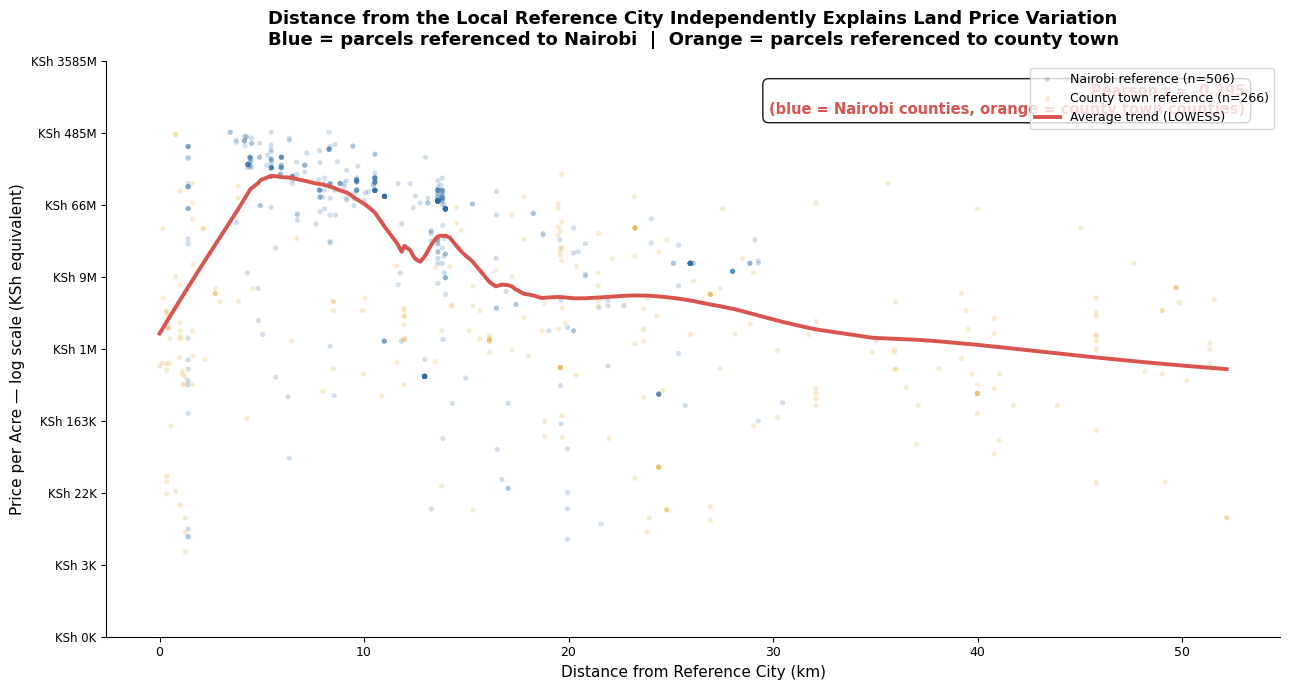

Pearson r: -0.395


In [7]:
plot_df2 = df[df["reference_city_dist_km"].notna() &
              (df["reference_city_dist_km"] <= df["reference_city_dist_km"].quantile(0.97))].copy()

plot_df2["ref_type"] = np.where(
    plot_df2["reference_city"] == "Nairobi", "Nairobi reference", "County town reference"
)

fig, ax = plt.subplots(figsize=(13, 7))

color_map = {"Nairobi reference": BLUE, "County town reference": ORANGE}
for rtype, color in color_map.items():
    sub = plot_df2[plot_df2["ref_type"] == rtype]
    ax.scatter(sub["reference_city_dist_km"], sub["log_price_per_acre"],
               alpha=0.22, s=14, color=color, edgecolors="none",
               label=f"{rtype} (n={len(sub):,})", zorder=2)

# LOWESS on full dataset
ss  = plot_df2.sort_values("reference_city_dist_km")
sm2 = lowess(ss["log_price_per_acre"], ss["reference_city_dist_km"], frac=0.3)
ax.plot(sm2[:, 0], sm2[:, 1], color=RED, linewidth=2.8,
        label="Average trend (LOWESS)", zorder=4)

r2 = plot_df2["reference_city_dist_km"].corr(plot_df2["log_price_per_acre"])
ax.text(0.97, 0.96,
        f"Pearson r = {r2:.3f}\n(blue = Nairobi counties, orange = county town counties)",
        transform=ax.transAxes, ha="right", va="top", fontsize=10.5,
        fontweight="bold", color=RED,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.90))

yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels(
    [f"KSh {np.exp(y)/1e6:.0f}M" if np.exp(y)>=1e6
     else f"KSh {np.exp(y)/1e3:.0f}K" for y in yticks], fontsize=8.5
)

ax.set_title(
    "Distance from the Local Reference City Independently Explains Land Price Variation\n"
    "Blue = parcels referenced to Nairobi  |  Orange = parcels referenced to county town",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Distance from Reference City (km)", fontsize=11)
ax.set_ylabel("Price per Acre — log scale (KSh equivalent)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart3b_town_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Pearson r: {r2:.3f}")


## Charts 4A–4C — Score Distribution Histograms

The next three cells share a reusable helper function `score_histogram()` that is defined below.
Each chart answers: **how is this composite score distributed across all listings?**


In [8]:
from scipy.stats import gaussian_kde

def score_histogram(score_col, score_label, color, filename, title):
    """Plot a histogram + KDE overlay for a score column, with mean/median lines
    and a summary statistics annotation box."""
    raw = df[score_col].dropna()
    # If >50 % of values are exactly zero, show only the non-zero tail and add a note
    if (raw == 0).mean() > 0.5:
        sub = raw[raw > 0]
    else:
        sub = raw

    fig, ax = plt.subplots(figsize=(13, 7))

    counts, bin_edges, _ = ax.hist(
        sub, bins=30, color=color, alpha=0.72,
        edgecolor="white", linewidth=0.6, zorder=2
    )

    # KDE overlay — smoothed density curve scaled to count axis
    kde_x = np.linspace(sub.min(), sub.max(), 300)
    kde   = gaussian_kde(sub, bw_method="scott")
    kde_y = kde(kde_x) * len(sub) * (bin_edges[1] - bin_edges[0])
    ax.plot(kde_x, kde_y, color=DARK, linewidth=2.2,
            label="KDE (smoothed density)", zorder=4)

    # Mean and median reference lines
    mean_val   = sub.mean()
    median_val = sub.median()
    ax.axvline(mean_val,   color=RED,    linewidth=1.8, linestyle="--",
               label=f"Mean = {mean_val:.1f}", zorder=5)
    ax.axvline(median_val, color=ORANGE, linewidth=1.8, linestyle=":",
               label=f"Median = {median_val:.1f}", zorder=5)

    # Summary statistics annotation
    q25, q75 = sub.quantile(0.25), sub.quantile(0.75)
    stats_text = (
        f"n = {len(sub):,}\n"
        f"Mean   = {mean_val:.1f}\n"
        f"Median = {median_val:.1f}\n"
        f"Std    = {sub.std():.1f}\n"
        f"IQR    = [{q25:.1f}, {q75:.1f}]"
    )
    ax.text(0.97, 0.96, stats_text,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, fontfamily="monospace", color=DARK,
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      alpha=0.92, edgecolor="#cccccc"))

    # Zero-inflation notice
    n_zeros   = (raw == 0).sum()
    pct_zeros = n_zeros / len(raw) * 100
    if pct_zeros > 10:
        ax.text(0.03, 0.96,
                f"Note: {n_zeros:,} listings ({pct_zeros:.0f}%) score exactly 0\n"
                f"(description silent — not necessarily absent)",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=9, color=GREY,
                bbox=dict(boxstyle="round,pad=0.35", facecolor=LIGHT,
                          alpha=0.90, edgecolor="#cccccc"))

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{score_label} (0 = poorest access  |  100 = best access)", fontsize=11)
    ax.set_ylabel("Number of Listings", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{OUTPUTS}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}  |  n={len(sub):,}  mean={mean_val:.2f}  "
          f"median={median_val:.2f}  std={sub.std():.2f}")

print("score_histogram() helper defined.")


score_histogram() helper defined.


### Chart 4A — Distribution of Amenities Scores Across All Listings

**Question:** How are amenities scores distributed across the dataset — are most
listings clustered at the low end (poor service access), or is the distribution
broadly spread, indicating genuine variation in the feature?

**How to interpret:** A distribution piled up at 0 means most listings have poor or
unscored amenity access. A roughly bell-shaped distribution means the score captures
real variation. A bimodal shape may indicate two distinct listing populations (urban vs rural).


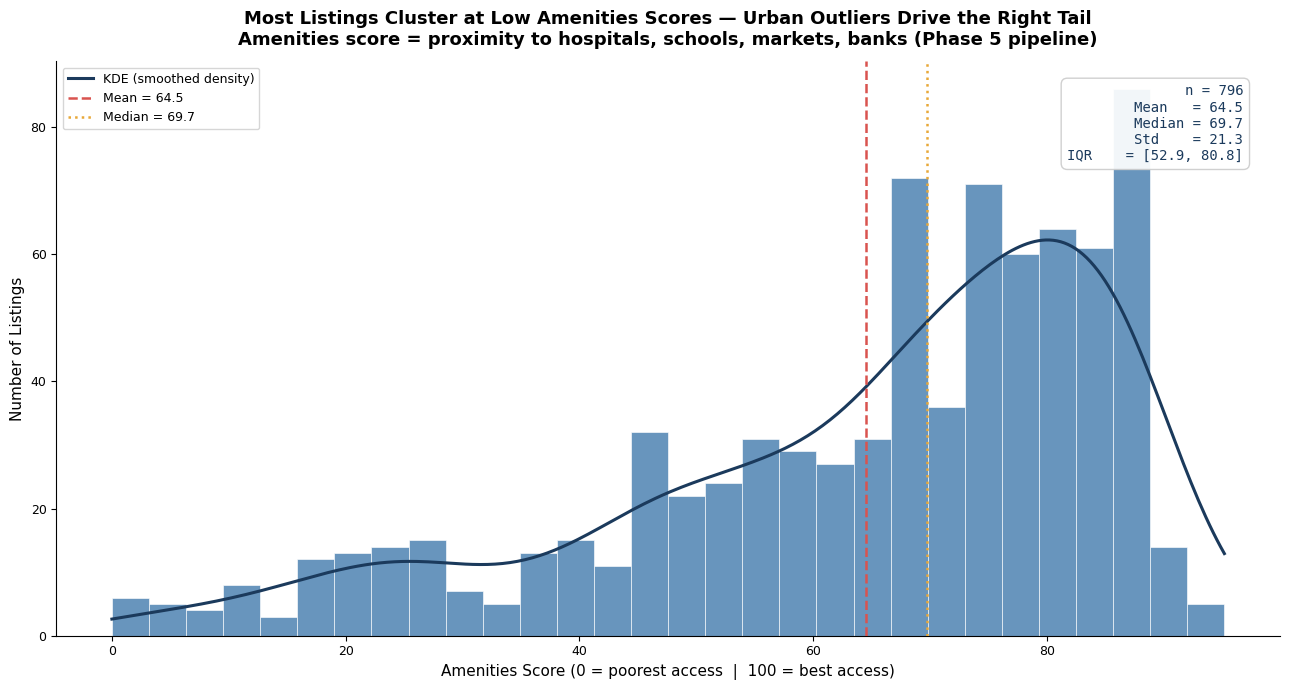

Saved: chart4a_amenities_score.png  |  n=796  mean=64.53  median=69.74  std=21.30


In [9]:
score_histogram(
    "amenities_score", "Amenities Score", BLUE,
    "chart4a_amenities_score.png",
    "Most Listings Cluster at Low Amenities Scores — Urban Outliers Drive the Right Tail\n"
    "Amenities score = proximity to hospitals, schools, markets, banks (Phase 5 pipeline)"
)


### Chart 4B — Distribution of Accessibility Scores Across All Listings

**Question:** How are accessibility scores distributed — does road access vary widely
across listings, or do most cluster at similar levels?

**How to interpret:** Compare the shape here to Chart 4A (amenities). If accessibility
scores are more uniformly spread than amenities scores, road access is a more
discriminating feature. A strong right-skew would mean most land has poor
road access, with a small premium tier of well-connected parcels.


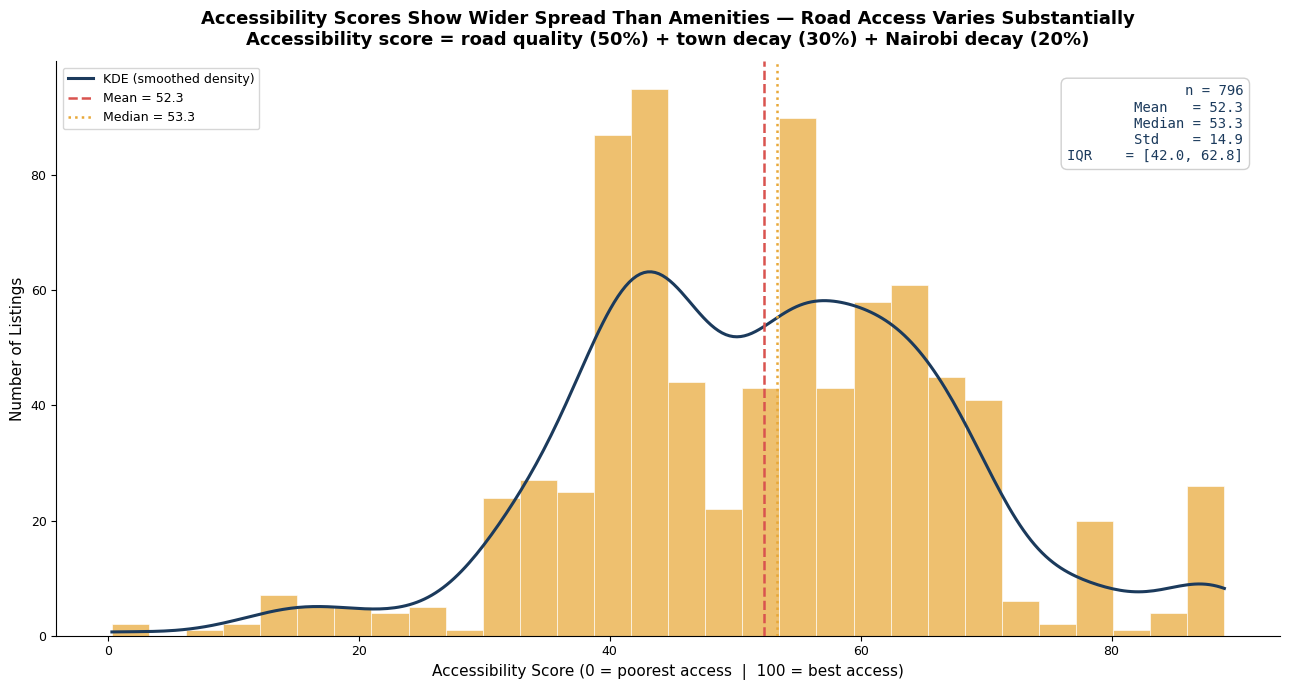

Saved: chart4b_accessibility_score.png  |  n=796  mean=52.27  median=53.35  std=14.93


In [10]:
score_histogram(
    "accessibility_score", "Accessibility Score", ORANGE,
    "chart4b_accessibility_score.png",
    "Accessibility Scores Show Wider Spread Than Amenities — Road Access Varies Substantially\n"
    "Accessibility score = road quality (50%) + town decay (30%) + Nairobi decay (20%)"
)


### Chart 4C — Distribution of Infrastructure Scores Across All Listings

**Question:** How are infrastructure scores distributed — and what share of listings
describe on-site infrastructure (borehole, electricity, fencing) vs those that are silent?

**Important context:** The infrastructure score is extracted from free-text listing
descriptions via NLP regex. A score of 0 means the description did not mention
infrastructure — not that the land has none.

**How to interpret:** Focus on the non-zero bars. If they are uniformly spread from
20 to 100, the extraction captured a genuine range of infrastructure quality. If
the non-zero bars cluster tightly around a single value, the score may have limited
discriminating power and a binary flag might be more informative.


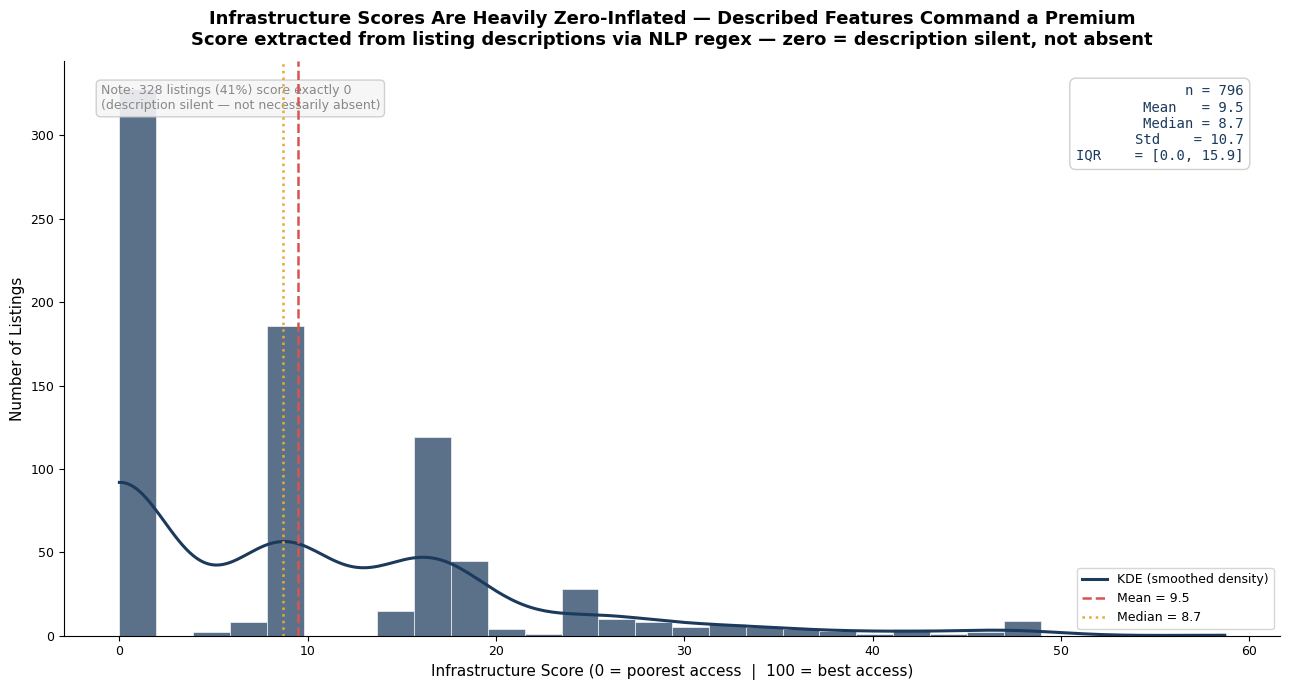

Saved: chart4c_infrastructure_score.png  |  n=796  mean=9.50  median=8.70  std=10.66


In [11]:
score_histogram(
    "infrastructure_score", "Infrastructure Score", DARK,
    "chart4c_infrastructure_score.png",
    "Infrastructure Scores Are Heavily Zero-Inflated — Described Features Command a Premium\n"
    "Score extracted from listing descriptions via NLP regex — zero = description silent, not absent"
)


## Chart 5 — Kenya's Land Value Landscape: A Continuous Price Surface from Nairobi to the Coast

**Question:** What would the price per acre look like if you could read it continuously
across Kenya's geography, filling the gaps between actual listing locations?

**Method:** Inverse Distance Weighting (IDW) assigns each grid cell a weighted average
of nearby listing prices (weight = 1/distance²). Log-transformed prices are interpolated
to reduce outlier influence; colourbar labels convert back to KSh for readability.

**Best practice applied:**
- `shading="gouraud"` produces smooth bilinear colour transitions
- White no-data regions are explicitly explained in a footnote annotation
- Log scale interpolation prevents luxury Nairobi listings from washing out cheaper regions

**How to interpret:** The Nairobi-Kiambu warm zone and the Mombasa coastal hotspot are
the two dominant price hubs. White areas are data gaps — not cheap land.


Computing IDW surface...
Done.


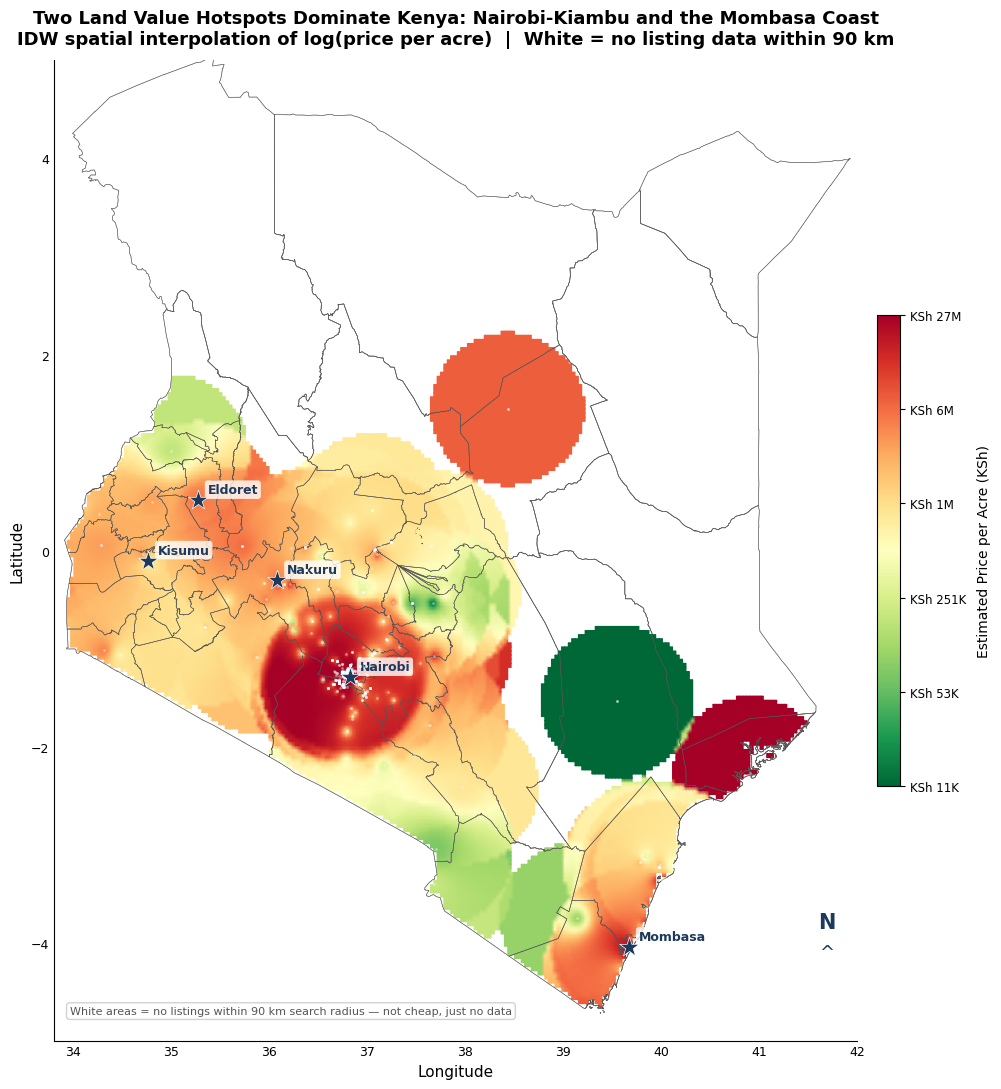

Saved: chart5_idw_price_surface.png


In [12]:
from shapely.vectorized import contains as shp_contains

idw_df = gdf[gdf["price_per_acre"].notna() &
             (gdf["price_per_acre"] >= p01) &
             (gdf["price_per_acre"] <= p99)].copy()

lons       = idw_df.geometry.x.values
lats       = idw_df.geometry.y.values
log_prices = np.log(idw_df["price_per_acre"].values)

GRID_RES  = 240
LON_RANGE = (33.8, 42.0)
LAT_RANGE = (-5.0,  5.0)
SEARCH_R  = 0.80   # degrees (~90 km)
POWER     = 2

lon_grid = np.linspace(*LON_RANGE, GRID_RES)
lat_grid = np.linspace(*LAT_RANGE, GRID_RES)
GLON, GLAT = np.meshgrid(lon_grid, lat_grid)

print("Computing IDW surface...")
Z = np.zeros(GLON.shape); W = np.zeros(GLON.shape)
IN_RANGE = np.zeros(GLON.shape, dtype=bool)

for i in range(len(lons)):
    dist    = np.sqrt((GLON - lons[i])**2 + (GLAT - lats[i])**2)
    within  = dist <= SEARCH_R
    w       = np.where(within, 1.0 / np.maximum(dist, 1e-8)**POWER, 0.0)
    Z      += w * log_prices[i]
    W      += w
    IN_RANGE |= within

with np.errstate(invalid="ignore", divide="ignore"):
    Z_idw = np.where(W > 0, Z / W, np.nan)

kenya_union = counties_gdf.union_all()
inside  = shp_contains(kenya_union, GLON.ravel(), GLAT.ravel()).reshape(GLON.shape)
Z_final = np.where(inside & IN_RANGE, Z_idw, np.nan)
print("Done.")

fig, ax = plt.subplots(figsize=(13, 11))
ax.set_facecolor("white")

counties_gdf.plot(ax=ax, color="white", edgecolor="#aaaaaa", linewidth=0.45, zorder=1)

vmin     = np.nanpercentile(Z_final, 5)
vmax     = np.nanpercentile(Z_final, 95)
Z_masked = np.ma.masked_invalid(Z_final)

pcm = ax.pcolormesh(GLON, GLAT, Z_masked, cmap="RdYlGn_r",
                    vmin=vmin, vmax=vmax, shading="gouraud", zorder=2)

counties_gdf.boundary.plot(ax=ax, color="#555555", linewidth=0.4, zorder=3)
ax.scatter(gdf.geometry.x, gdf.geometry.y,
           s=4, color="white", alpha=0.40, zorder=4, linewidths=0)

cbar = plt.colorbar(pcm, ax=ax, shrink=0.48, pad=0.015)
cbar.set_label("Estimated Price per Acre (KSh)", fontsize=10, labelpad=8)
log_ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(log_ticks)
cbar.set_ticklabels(
    [f"KSh {np.exp(v)/1e6:.0f}M" if np.exp(v)>=1e6
     else f"KSh {np.exp(v)/1e3:.0f}K" for v in log_ticks], fontsize=8.5
)

for city, (lat, lon) in CITIES.items():
    ax.scatter(lon, lat, marker="*", s=220, color=DARK,
               zorder=6, edgecolors="white", linewidths=0.5)
    ax.annotate(city, (lon, lat), textcoords="offset points", xytext=(7, 5),
                fontsize=9, fontweight="bold", color=DARK,
                bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                          alpha=0.80, edgecolor="none"))

ax.text(0.02, 0.025,
        "White areas = no listings within 90 km search radius — not cheap, just no data",
        transform=ax.transAxes, fontsize=8, color="#555555", va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  alpha=0.88, edgecolor="#cccccc"))

ax.annotate("N", xy=(0.962, 0.115), xycoords="axes fraction",
            fontsize=15, fontweight="bold", ha="center", color=DARK)
ax.annotate("^", xy=(0.962, 0.085), xycoords="axes fraction",
            fontsize=13, ha="center", color=DARK)

ax.set_title(
    "Two Land Value Hotspots Dominate Kenya: Nairobi-Kiambu and the Mombasa Coast\n"
    "IDW spatial interpolation of log(price per acre)  |  White = no listing data within 90 km",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.set_xlim(*LON_RANGE)
ax.set_ylim(*LAT_RANGE)
ax.tick_params(which="both", length=0)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart5_idw_price_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart5_idw_price_surface.png")


## Chart 6 — Where Should You Invest? Top 5 Counties Balancing Price, Services, and Access

**Question:** Which five counties offer the best combination of affordability, amenities,
accessibility, infrastructure quality, and proximity to a reference city?

**Scoring weights:**
- Affordability (inverse of median price per acre): 35 %
- Amenities score: 20 %
- Accessibility score: 20 %
- Infrastructure score: 15 %
- Proximity (inverse of reference city distance): 10 %

**How to interpret:** The longest total bar is the best overall county. Read the individual
coloured segments to understand *why* each county ranks where it does.


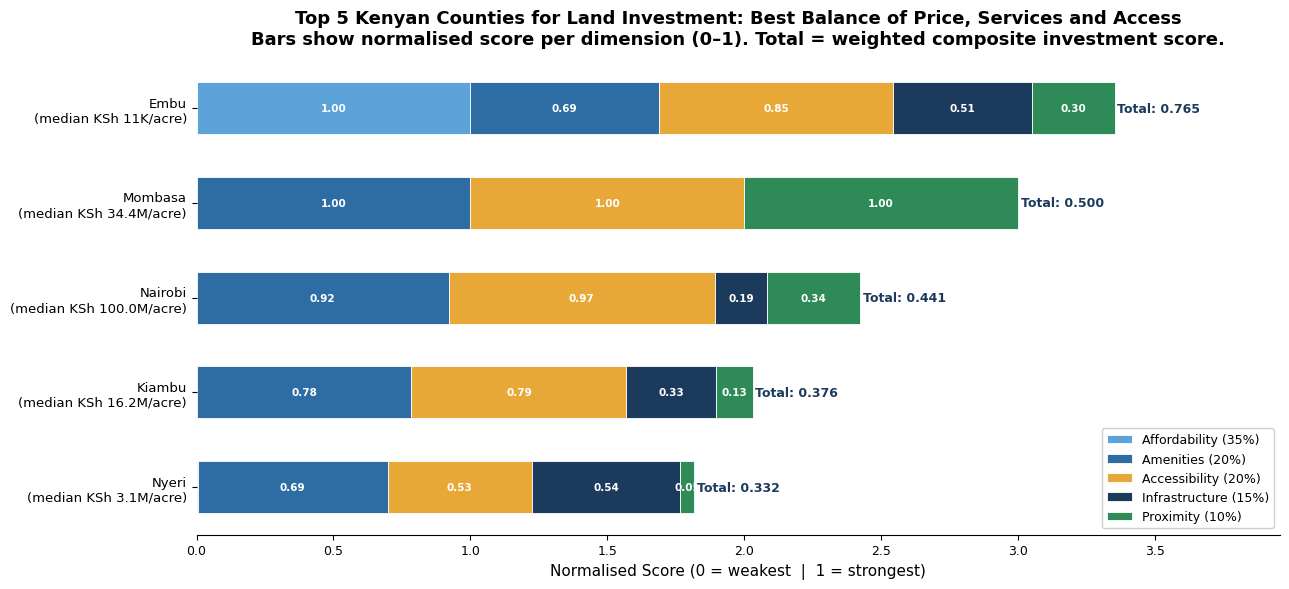

Top 5 counties composite investment scores:
 county  count      median_ppa  composite
   Embu      7      KSh 11,000   0.765033
Mombasa      9  KSh 34,438,226   0.500073
Nairobi    352 KSh 100,000,000   0.441064
 Kiambu    117  KSh 16,250,000   0.376437
  Nyeri     19   KSh 3,125,000   0.331923


In [13]:
score_df = df.groupby("county").agg(
    median_ppa         = ("price_per_acre",        "median"),
    mean_amenities     = ("amenities_score",       "mean"),
    mean_accessibility = ("accessibility_score",   "mean"),
    mean_infra         = ("infrastructure_score",  "mean"),
    mean_ref_dist      = ("reference_city_dist_km","mean"),
    count              = ("price_per_acre",         "count")
).reset_index()

score_df = score_df[score_df["count"] >= 5].copy()

def norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

score_df["afford_score"] = norm(1 / score_df["median_ppa"])
score_df["amen_score"]   = norm(score_df["mean_amenities"])
score_df["access_score"] = norm(score_df["mean_accessibility"])
score_df["infra_score"]  = norm(score_df["mean_infra"])
score_df["prox_score"]   = norm(1 / (score_df["mean_ref_dist"] + 1))

W = {"afford": 0.35, "amen": 0.20, "access": 0.20, "infra": 0.15, "prox": 0.10}
score_df["composite"] = (
    W["afford"] * score_df["afford_score"] +
    W["amen"]   * score_df["amen_score"]   +
    W["access"] * score_df["access_score"] +
    W["infra"]  * score_df["infra_score"]  +
    W["prox"]   * score_df["prox_score"]
)

top5 = score_df.nlargest(5, "composite").reset_index(drop=True)
top5 = top5.sort_values("composite")  # ascending → best at top

dims = [
    ("afford_score", f"Affordability ({W['afford']*100:.0f}%)", "#5BA3D9"),
    ("amen_score",   f"Amenities ({W['amen']*100:.0f}%)",       BLUE),
    ("access_score", f"Accessibility ({W['access']*100:.0f}%)", ORANGE),
    ("infra_score",  f"Infrastructure ({W['infra']*100:.0f}%)", DARK),
    ("prox_score",   f"Proximity ({W['prox']*100:.0f}%)",       GREEN),
]

fig, ax = plt.subplots(figsize=(13, 6))
y_pos = range(len(top5))
left  = np.zeros(len(top5))

for col, label, color in dims:
    vals = top5[col].values
    bars = ax.barh(y_pos, vals, left=left, color=color,
                   edgecolor="white", linewidth=0.6, label=label, height=0.55)
    for bar, v in zip(bars, vals):
        if v > 0.04:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{v:.2f}", ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    left += vals

ylabels = []
for _, row in top5.iterrows():
    ppa = row["median_ppa"]
    ppa_str = f"KSh {ppa/1e6:.1f}M" if ppa >= 1e6 else f"KSh {ppa/1e3:.0f}K"
    ylabels.append(f"{row['county']}\n(median {ppa_str}/acre)")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(ylabels, fontsize=9.5)

for i, (_, row) in enumerate(top5.iterrows()):
    ax.text(left[i] + 0.01, i, f"Total: {row['composite']:.3f}",
            va="center", fontsize=9, fontweight="bold", color=DARK)

ax.set_title(
    "Top 5 Kenyan Counties for Land Investment: Best Balance of Price, Services and Access\n"
    "Bars show normalised score per dimension (0–1). Total = weighted composite investment score.",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Normalised Score (0 = weakest  |  1 = strongest)", fontsize=11)
ax.set_xlim(0, left.max() * 1.18)
ax.legend(loc="lower right", fontsize=9, framealpha=0.92)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart6_top5_investment_counties.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 counties composite investment scores:")
print(top5[["county","count","median_ppa","composite"]]
      .sort_values("composite", ascending=False)
      .assign(median_ppa=lambda d: d["median_ppa"].apply(lambda x: f"KSh {x:,.0f}"))
      .to_string(index=False))


## Chart 7 — Larger Parcels Cost More in Total but Less per Acre — The Bulk Discount Effect

**Question:** Does buying more acres give you a better price per acre, and how strong
is this bulk discount in the Kenyan land market?

**Best practice applied:**
- Both axes are log-transformed — raw price and raw size span multiple orders of magnitude
- Trend line slope is annotated — on a log-log plot, slope < 1 means per-acre discount
- Dot colour encodes price per acre (third variable)

**How to interpret:** A trend line slope less than 1.0 confirms a bulk discount. The annotation
interprets this directly in plain language. Outliers far from the band are unusual parcels
worth individual investigation.


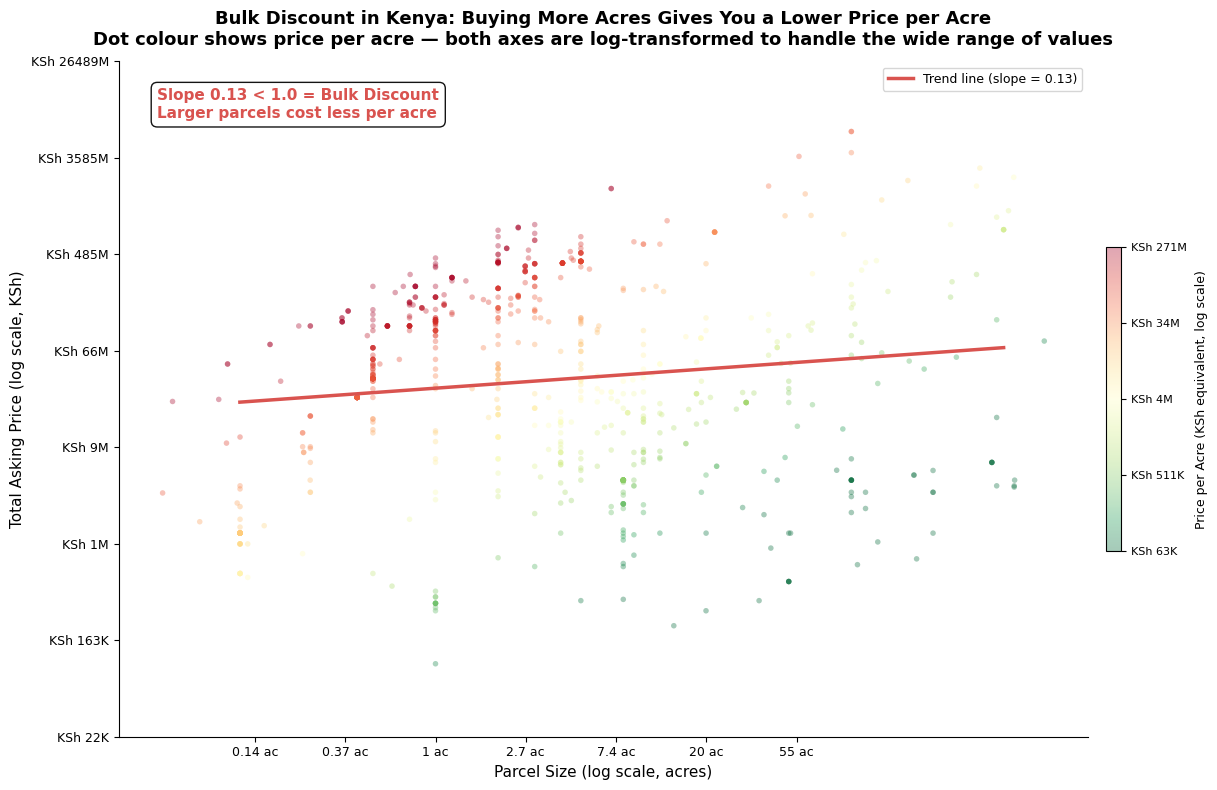

Log-log slope: 0.134
Interpretation: slope < 1 = bulk discount, slope > 1 = size premium


In [14]:
plot_size = df[(df["size_acres"] > 0) &
               df["log_size_acres"].notna() &
               df["log_price_per_acre"].notna()].copy()

plot_size["log_total_price"] = plot_size["log_price_per_acre"] + plot_size["log_size_acres"]

fig, ax = plt.subplots(figsize=(13, 8))

sc = ax.scatter(
    plot_size["log_size_acres"],
    plot_size["log_total_price"],
    c=plot_size["log_price_per_acre"],
    cmap="RdYlGn_r", alpha=0.35, s=16,
    edgecolors="none", zorder=2,
    norm=mcolors.Normalize(
        vmin=plot_size["log_price_per_acre"].quantile(0.05),
        vmax=plot_size["log_price_per_acre"].quantile(0.95)
    )
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.45, pad=0.015)
cbar.set_label("Price per Acre (KSh equivalent, log scale)", fontsize=9, labelpad=6)
lt = np.linspace(plot_size["log_price_per_acre"].quantile(0.05),
                 plot_size["log_price_per_acre"].quantile(0.95), 5)
cbar.set_ticks(lt)
cbar.set_ticklabels(
    [f"KSh {np.exp(v)/1e6:.0f}M" if np.exp(v)>=1e6
     else f"KSh {np.exp(v)/1e3:.0f}K" for v in lt], fontsize=8
)

slope, intercept = np.polyfit(plot_size["log_size_acres"],
                               plot_size["log_total_price"], 1)
x_line = np.linspace(plot_size["log_size_acres"].quantile(0.01),
                     plot_size["log_size_acres"].quantile(0.99), 200)
ax.plot(x_line, intercept + slope * x_line, color=RED,
        linewidth=2.5, label=f"Trend line (slope = {slope:.2f})", zorder=4)

if slope < 1:
    interp = f"Slope {slope:.2f} < 1.0 = Bulk Discount\nLarger parcels cost less per acre"
elif slope > 1:
    interp = f"Slope {slope:.2f} > 1.0 = Size Premium\nLarger parcels cost more per acre"
else:
    interp = f"Slope {slope:.2f} ≈ 1.0 = No bulk effect"

ax.text(0.04, 0.96, interp, transform=ax.transAxes, ha="left", va="top",
        fontsize=11, fontweight="bold", color=RED,
        bbox=dict(boxstyle="round,pad=0.40", facecolor="white", alpha=0.92))

xt = [-2, -1, 0, 1, 2, 3, 4]
ax.set_xticks(xt)
ax.set_xticklabels([f"{np.exp(v):.2g} ac" for v in xt], fontsize=9)

yt = ax.get_yticks()
ax.set_yticks(yt)
ax.set_yticklabels(
    [f"KSh {np.exp(y)/1e6:.0f}M" if np.exp(y)>=1e6
     else f"KSh {np.exp(y)/1e3:.0f}K" for y in yt], fontsize=9
)

ax.set_title(
    "Bulk Discount in Kenya: Buying More Acres Gives You a Lower Price per Acre\n"
    "Dot colour shows price per acre — both axes are log-transformed to handle the wide range of values",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Parcel Size (log scale, acres)", fontsize=11)
ax.set_ylabel("Total Asking Price (log scale, KSh)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart7_size_vs_price_loglog.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-log slope: {slope:.3f}")
print("Interpretation: slope < 1 = bulk discount, slope > 1 = size premium")


## Chart 8 — Which Features Predict Land Price Most Strongly, and Which Are Redundant?

**Question:** Looking at all engineered features simultaneously, which ones have the
strongest linear association with price per acre, and which pairs of features are so
correlated with each other that one may be redundant in the model?

**Best practice applied:**
- Lower-triangle only — each pair appears once; the upper triangle is masked
- RdBu_r diverging palette centred at zero — red = positive, blue = negative
- Values annotated in each cell
- Features reordered so the target (price per acre) appears first

**How to interpret:**
- **First row** — correlations with price per acre. Red = good predictor. Blue = inverse predictor.
- **Off-diagonal cells** — any |r| > 0.80 between two input features suggests potential redundancy.


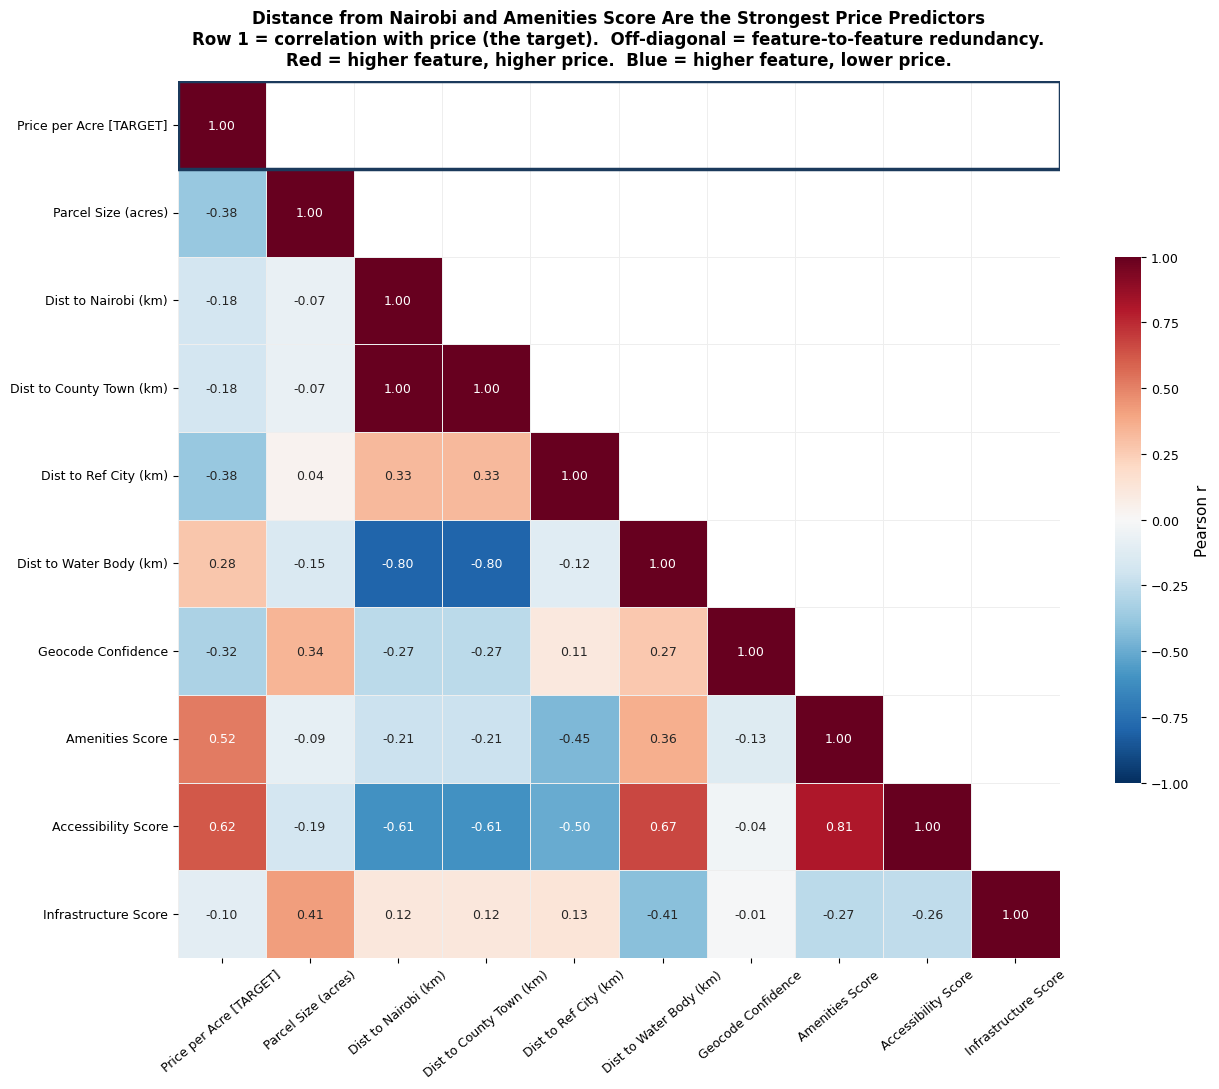

Correlations with Price per Acre (strongest to weakest):
  Accessibility Score           : +0.618  ##################
  Amenities Score               : +0.523  ###############
  Parcel Size (acres)           : -0.378  ###########
  Dist to Ref City (km)         : -0.378  ###########
  Geocode Confidence            : -0.315  #########
  Dist to Water Body (km)       : +0.279  ########
  Dist to County Town (km)      : -0.180  #####
  Dist to Nairobi (km)          : -0.180  #####
  Infrastructure Score          : -0.103  ###

Feature pairs with |r| > 0.70 (potential redundancy):
  Dist to Nairobi (km)  vs  Dist to County Town (km)  :  +1.000
  Amenities Score  vs  Accessibility Score  :  +0.812
  Dist to Nairobi (km)  vs  Dist to Water Body (km)  :  -0.798
  Dist to County Town (km)  vs  Dist to Water Body (km)  :  -0.798


In [15]:
CORR_COLS = [
    "price_per_acre",
    "size_acres",
    "dist_to_nairobi_km",
    "dist_to_county_town_km",
    "reference_city_dist_km",
    "dist_to_water_body_km",
    "geocode_confidence",
    "amenities_score",
    "accessibility_score",
    "infrastructure_score",
]

CORR_LABELS = [
    "Price per Acre [TARGET]",
    "Parcel Size (acres)",
    "Dist to Nairobi (km)",
    "Dist to County Town (km)",
    "Dist to Ref City (km)",
    "Dist to Water Body (km)",
    "Geocode Confidence",
    "Amenities Score",
    "Accessibility Score",
    "Infrastructure Score",
]

corr_df  = df[CORR_COLS].dropna()
corr_mat = corr_df.corr().round(3)
corr_mat.index   = CORR_LABELS
corr_mat.columns = CORR_LABELS

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr_mat, ax=ax, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.6, linecolor="#eeeeee",
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.60, "label": "Pearson r"}
)

ax.add_patch(plt.Rectangle((0, 0), len(CORR_LABELS), 1,
             fill=False, edgecolor=DARK, lw=2.5, zorder=5))

ax.set_title(
    "Distance from Nairobi and Amenities Score Are the Strongest Price Predictors\n"
    "Row 1 = correlation with price (the target).  Off-diagonal = feature-to-feature redundancy.\n"
    "Red = higher feature, higher price.  Blue = higher feature, lower price.",
    fontsize=12, fontweight="bold"
)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/chart8_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

price_corrs = corr_mat.loc["Price per Acre [TARGET]"].drop("Price per Acre [TARGET]")
price_corrs = price_corrs.reindex(price_corrs.abs().sort_values(ascending=False).index)
print("Correlations with Price per Acre (strongest to weakest):")
for feat, val in price_corrs.items():
    bar = "#" * int(abs(val) * 30)
    print(f"  {feat:<30}: {val:+.3f}  {bar}")

high_pairs = [
    (corr_mat.index[i], corr_mat.columns[j], corr_mat.iloc[i,j])
    for i in range(1, len(CORR_LABELS))
    for j in range(i+1, len(CORR_LABELS))
    if abs(corr_mat.iloc[i,j]) > 0.70
]
if high_pairs:
    print("\nFeature pairs with |r| > 0.70 (potential redundancy):")
    for a, b, v in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f"  {a}  vs  {b}  :  {v:+.3f}")


## EDA Complete


In [16]:
charts = [
    ("Chart 1",  "chart1_geospatial_scatter.png",        "Geospatial scatter — price and parcel size"),
    ("Chart 2",  "chart2_choropleth_mean_price.png",      "Choropleth — mean price per county"),
    ("Chart 3A", "chart3a_nairobi_distance.png",          "Nairobi distance vs log price"),
    ("Chart 3B", "chart3b_town_distance.png",             "Reference city distance vs log price"),
    ("Chart 4A", "chart4a_amenities_score.png",           "Amenities score distribution histogram"),
    ("Chart 4B", "chart4b_accessibility_score.png",       "Accessibility score distribution histogram"),
    ("Chart 4C", "chart4c_infrastructure_score.png",      "Infrastructure score distribution histogram"),
    ("Chart 5",  "chart5_idw_price_surface.png",          "IDW continuous price surface"),
    ("Chart 6",  "chart6_top5_investment_counties.png",   "Top 5 counties to invest"),
    ("Chart 7",  "chart7_size_vs_price_loglog.png",       "Size vs total price (log-log)"),
    ("Chart 8",  "chart8_correlation_matrix.png",         "Correlation matrix"),
]

print("=" * 65)
print("EDA COMPLETE — ALL CHARTS")
print("=" * 65)
all_saved = True
for label, fname, desc in charts:
    path   = f"{OUTPUTS}/{fname}"
    saved  = os.path.exists(path)
    status = "saved" if saved else "MISSING"
    if not saved:
        all_saved = False
    print(f"  [{status}] {label} — {desc}")

print(f"\nOutput folder: {OUTPUTS}")
print(f"\nAll charts saved: {all_saved}")


EDA COMPLETE — ALL CHARTS
  [saved] Chart 1 — Geospatial scatter — price and parcel size
  [saved] Chart 2 — Choropleth — mean price per county
  [saved] Chart 3A — Nairobi distance vs log price
  [saved] Chart 3B — Reference city distance vs log price
  [saved] Chart 4A — Amenities score distribution histogram
  [saved] Chart 4B — Accessibility score distribution histogram
  [saved] Chart 4C — Infrastructure score distribution histogram
  [saved] Chart 5 — IDW continuous price surface
  [saved] Chart 6 — Top 5 counties to invest
  [saved] Chart 7 — Size vs total price (log-log)
  [saved] Chart 8 — Correlation matrix

Output folder: /content/drive/MyDrive/kenya_land_valuation/outputs/eda

All charts saved: True
